<a href="https://colab.research.google.com/github/feelsmandata/feelsmandata/blob/main/Uber_Data_ML_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
import matplotlib.pyplot as plt

In [ ]:
def read_file(filepath):
  if filepath.endswith('.csv'):
    data = pd.read_csv(filepath)
  elif filepath.endswith('.xlsx'):
    data = pd.read_excel(filepath)
  else:
    print('Please check file extension')
  return data

In [ ]:
file = r'/content/drive/MyDrive/Data Science/ncr_ride_bookings.csv'

In [ ]:
data = read_file(file)

In [ ]:
data.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [ ]:
data.describe()

,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,139500.000000,102000.000000,10500.0,27000.0,9000.0,102000.000000,102000.000000,93000.000000,93000.000000
mean,8.456352,29.149636,1.0,1.0,1.0,508.295912,24.637012,4.230992,4.404584
std,3.773564,8.902577,0.0,0.0,0.0,395.805774,14.002138,0.436871,0.437819
min,2.000000,10.000000,1.0,1.0,1.0,50.000000,1.000000,3.000000,3.000000
25%,5.300000,21.600000,1.0,1.0,1.0,234.000000,12.460000,4.100000,4.200000
50%,8.300000,28.800000,1.0,1.0,1.0,414.000000,23.720000,4.300000,4.500000
75%,11.300000,36.800000,1.0,1.0,1.0,689.000000,36.820000,4.600000,4.800000
max,20.000000,45.000000,1.0,1.0,1.0,4277.000000,50.000000,5.000000,5.000000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

In [ ]:
data.isnull().sum()

,0
Date,0
Time,0
Booking ID,0
Booking Status,0
Customer ID,0
Vehicle Type,0
Pickup Location,0
Drop Location,0
Avg VTAT,10500
Avg CTAT,48000


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.dtypes

,0
Date,object
Time,object
Booking ID,object
Booking Status,object
Customer ID,object
Vehicle Type,object
Pickup Location,object
Drop Location,object
Avg VTAT,float64
Avg CTAT,float64


In [ ]:
data.shape

(150000, 21)

In [ ]:
data.columns = data.columns.str.lower()
data.columns

Index(['date', 'time', 'booking id', 'booking status', 'customer id',
       'vehicle type', 'pickup location', 'drop location', 'avg vtat',
       'avg ctat', 'cancelled rides by customer',
       'reason for cancelling by customer', 'cancelled rides by driver',
       'driver cancellation reason', 'incomplete rides',
       'incomplete rides reason', 'booking value', 'ride distance',
       'driver ratings', 'customer rating', 'payment method'],
      dtype='object')

In [ ]:
data['date'] = pd.to_datetime(data['date'],errors='coerce')
data['time'] = pd.to_datetime(data['time'],format='%H:%M:%S',errors='coerce').dt.time

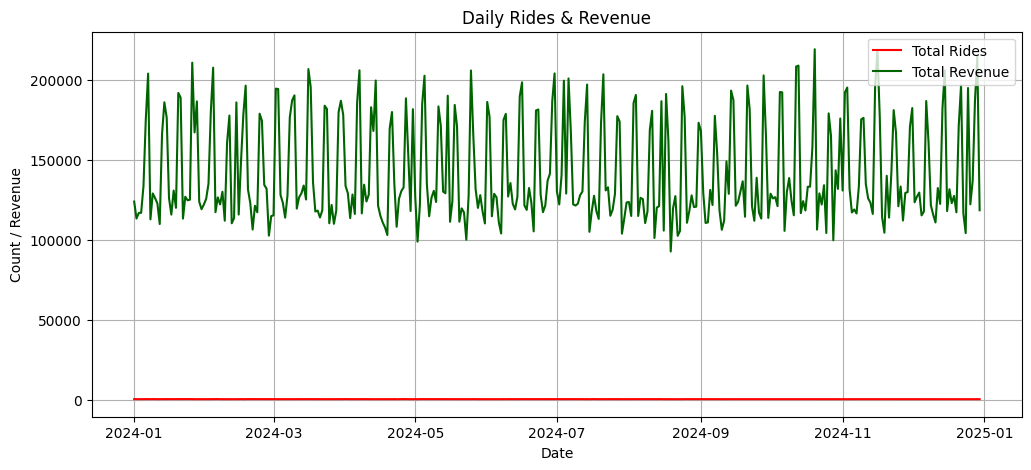

In [ ]:
daily_stats = data.groupby('date').agg({'booking id' : 'count','booking value' : 'sum'}).reset_index()
plt.figure(figsize=(12,5))
plt.plot(daily_stats['date'], daily_stats['booking id'], label="Total Rides", color='red')
plt.plot(daily_stats['date'], daily_stats['booking value'], label="Total Revenue", color='darkgreen')
plt.title("Daily Rides & Revenue")
plt.xlabel("Date")
plt.ylabel("Count / Revenue")
plt.legend()
plt.grid(True)

/tmp/ipython-input-1427385679.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='booking status', data = data,palette='viridis')


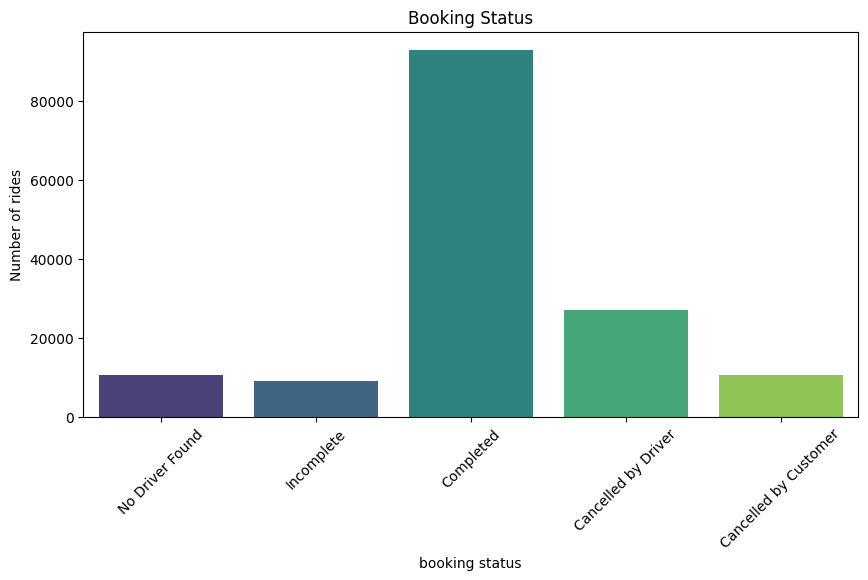

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='booking status', data = data,palette='viridis')
plt.title('Booking Status')
plt.ylabel('Number of rides')
plt.xticks(rotation=45)
plt.show()

/tmp/ipython-input-1148037808.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='vehicle type', data = data,order = data['vehicle type'].value_counts().index,palette='coolwarm')


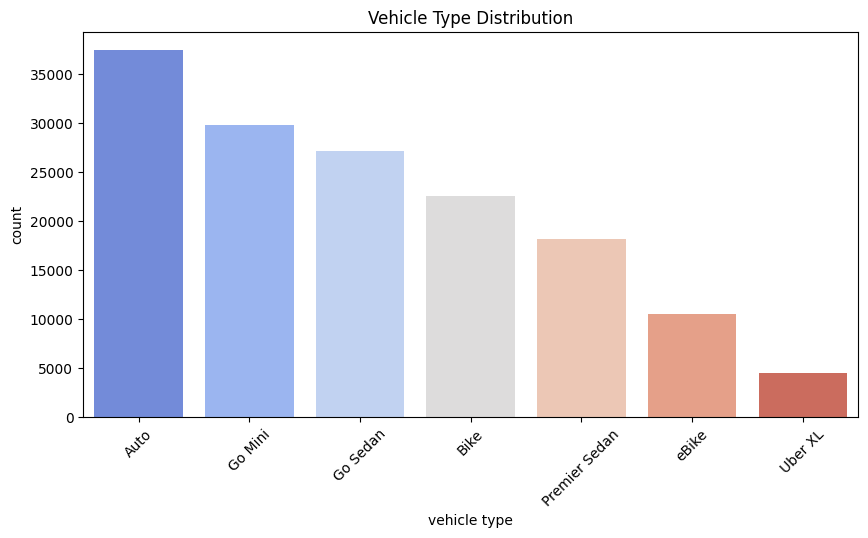

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='vehicle type', data = data,order = data['vehicle type'].value_counts().index,palette='coolwarm')
plt.title('Vehicle Type Distribution')
plt.xticks(rotation=45)
plt.show()

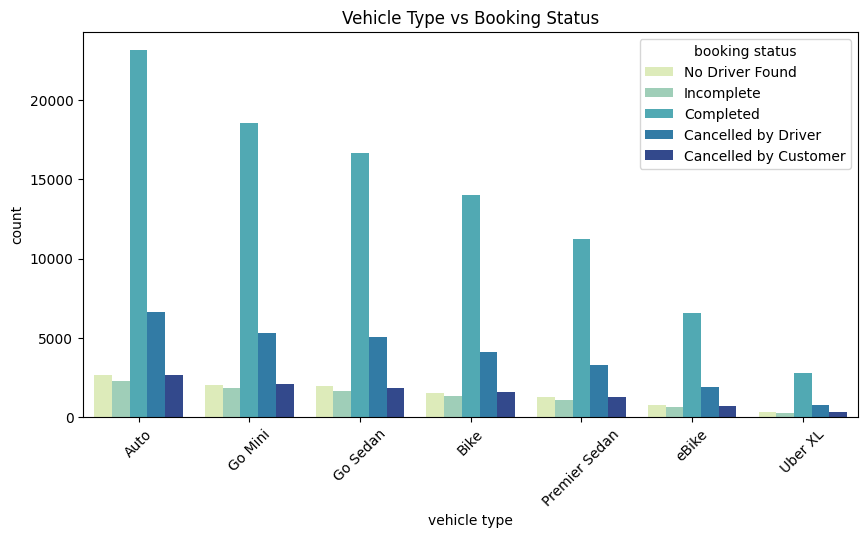

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x=data['vehicle type'], hue=data['booking status'], palette='YlGnBu', order=data['vehicle type'].value_counts().index)
plt.title('Vehicle Type vs Booking Status')
plt.xticks(rotation=45)
plt.show()

/tmp/ipython-input-1773919411.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_pickups.values,y=top_pickups.index, palette='Blues_r', ax=axes[0])
/tmp/ipython-input-1773919411.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_drops.values, y=top_drops.index, ax=axes[1], palette='Greens_r')


Text(0, 0.5, 'Location')

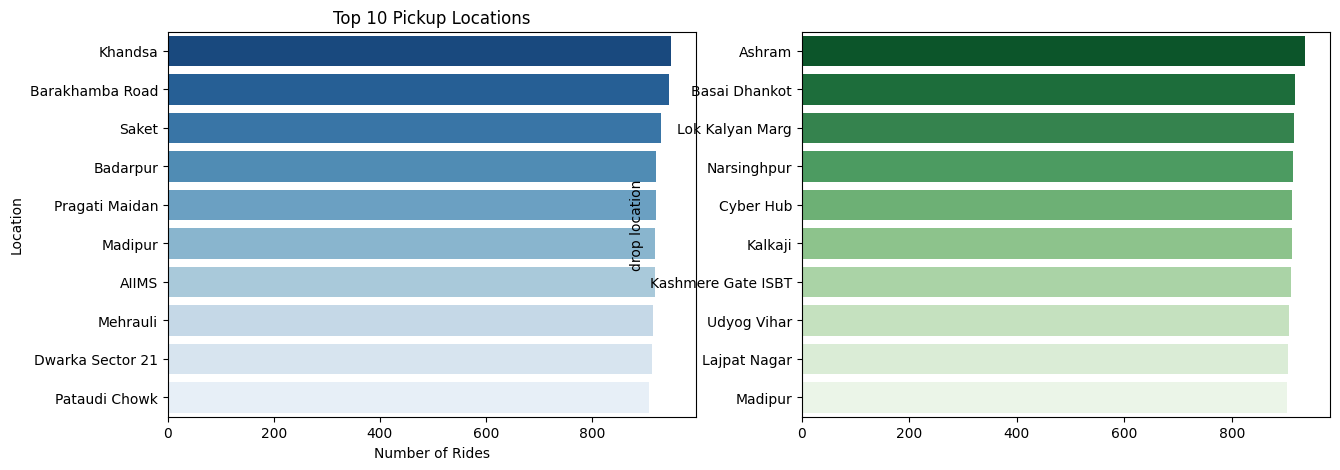

In [ ]:
top_pickups = data['pickup location'].value_counts().head(10)
top_drops = data['drop location'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(x=top_pickups.values,y=top_pickups.index, palette='Blues_r', ax=axes[0])
axes[0].set_title('Top 10 Pickup Locations')
sns.barplot(x=top_drops.values, y=top_drops.index, ax=axes[1], palette='Greens_r')
axes[0].set_xlabel('Number of Rides')
axes[0].set_ylabel('Location')

/tmp/ipython-input-703373907.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data['reason for cancelling by customer'], data = data, order = data['reason for cancelling by customer'].value_counts().index, ax = axes[0], palette='Reds')
/tmp/ipython-input-703373907.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data['driver cancellation reason'], data=data, order=data['driver cancellation reason'].value_counts().index, ax=axes[1], palette='Oranges')


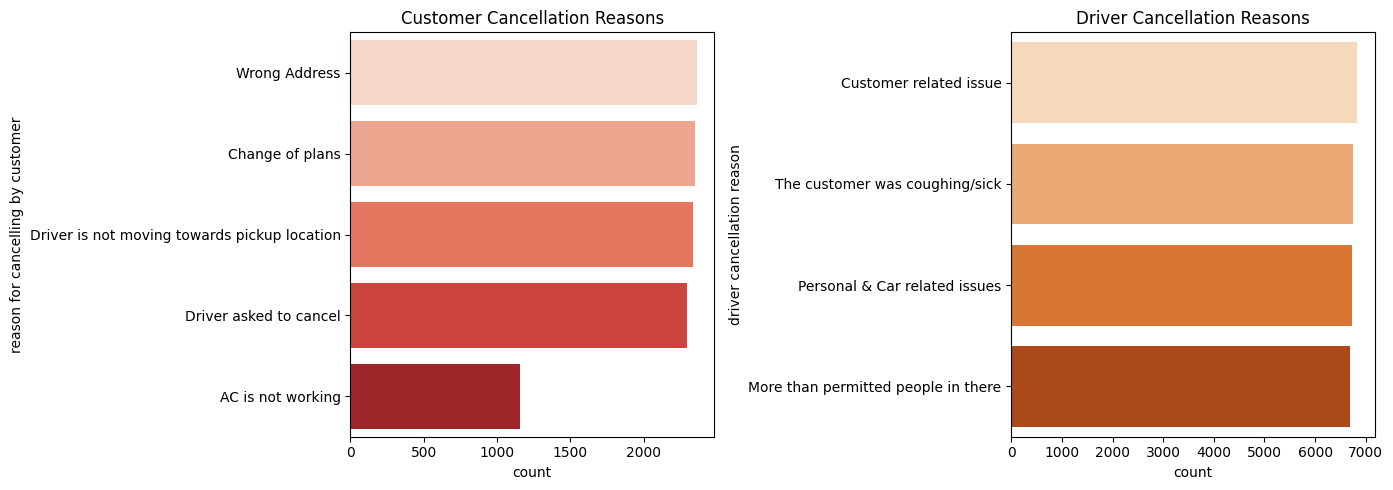

In [ ]:
fig, axes = plt.subplots(1,2, figsize = (14,5))
sns.countplot(y=data['reason for cancelling by customer'], data = data, order = data['reason for cancelling by customer'].value_counts().index, ax = axes[0], palette='Reds')
axes[0].set_title('Customer Cancellation Reasons')
sns.countplot(y=data['driver cancellation reason'], data=data, order=data['driver cancellation reason'].value_counts().index, ax=axes[1], palette='Oranges')
axes[1].set_title("Driver Cancellation Reasons")
plt.tight_layout()
plt.show()

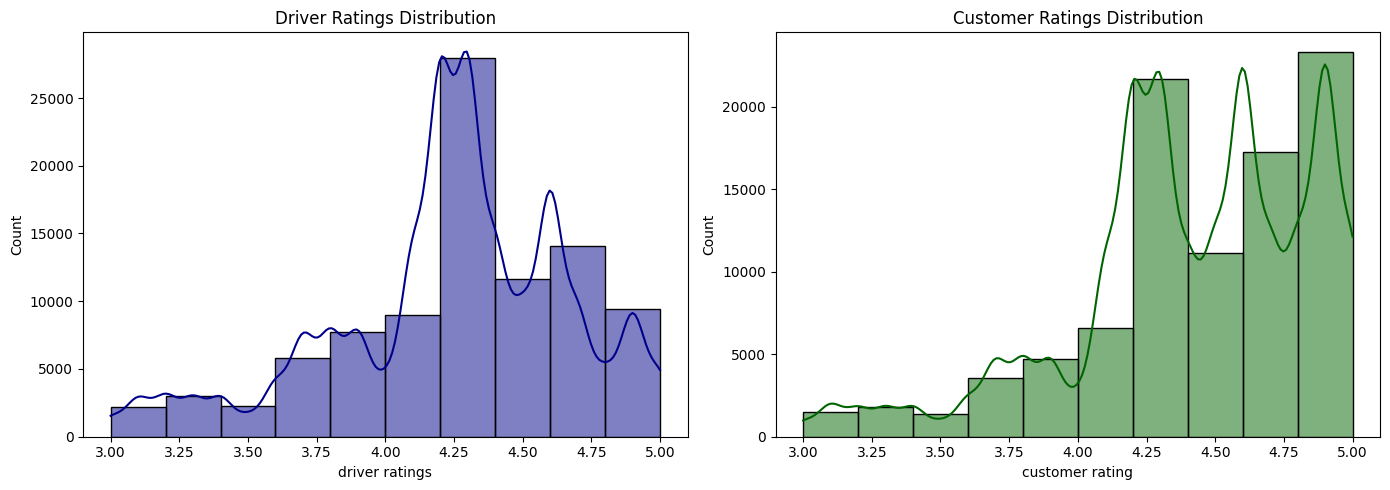

In [ ]:
fig, axes = plt.subplots(1,2, figsize = (14,5))
sns.histplot(data['driver ratings'], bins = 10, kde=True, ax=axes[0], color='darkblue')
axes[0].set_title('Driver Ratings Distribution')
sns.histplot(data['customer rating'], bins = 10, kde=True, ax=axes[1], color='darkgreen')
axes[1].set_title('Customer Ratings Distribution')
plt.tight_layout()
plt.show()

In [ ]:
data.columns

Index(['date', 'time', 'booking id', 'booking status', 'customer id',
       'vehicle type', 'pickup location', 'drop location', 'avg vtat',
       'avg ctat', 'cancelled rides by customer',
       'reason for cancelling by customer', 'cancelled rides by driver',
       'driver cancellation reason', 'incomplete rides',
       'incomplete rides reason', 'booking value', 'ride distance',
       'driver ratings', 'customer rating', 'payment method'],
      dtype='object')

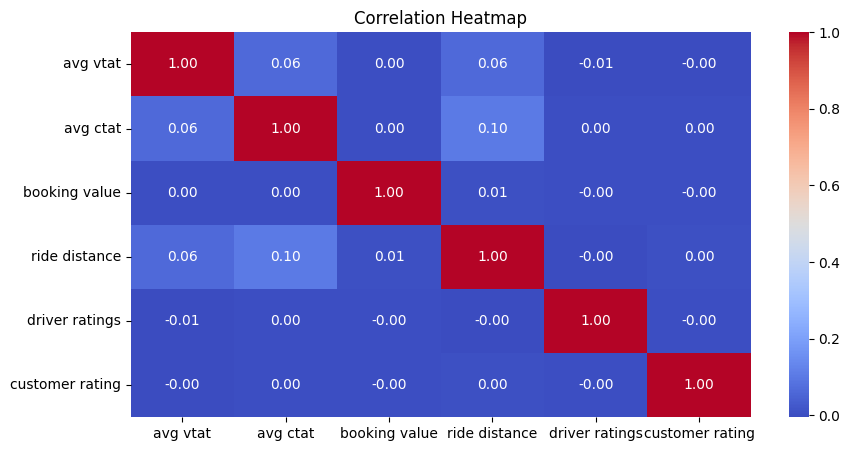

In [ ]:
cols = ['avg vtat', 'avg ctat', 'booking value', 'ride distance', 'driver ratings', 'customer rating']
plt.figure(figsize=(10,5))
sns.heatmap(data[cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

PREDICTIVE MODELING

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

In [ ]:
data['date'] = pd.to_datetime(data['date'], errors='coerce')
data['time'] = pd.to_datetime(data['time'],format='%H:%M:%S', errors='coerce')

data['year'] = data['date'].dt.year
data['month'] = data['date'].dt.month
data['day'] = data['date'].dt.day
data['hour'] = data['time'].dt.hour
data['minute'] = data['time'].dt.minute

data = data.drop(columns=['date', 'time'])
data = data.fillna('Unknown')

label_encoders = {}
for col in data.columns:
  if data[col].dtype == 'object' or isinstance(data[col].iloc[0],str):
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    label_encoders[col] = le

target_col = 'booking status'
X = data.drop(columns=target_col, axis=1)
y = data[target_col]

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


                 Model  Accuracy
0  Logistic Regression    100.00
1        Decision Tree    100.00
2        Random Forest    100.00
3          Naive Bayes    100.00
4                  SVM    100.00
5  K-Nearest Neighbors     99.96
6              XGBoost    100.00


/tmp/ipython-input-1205986941.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=results_df, palette='viridis')


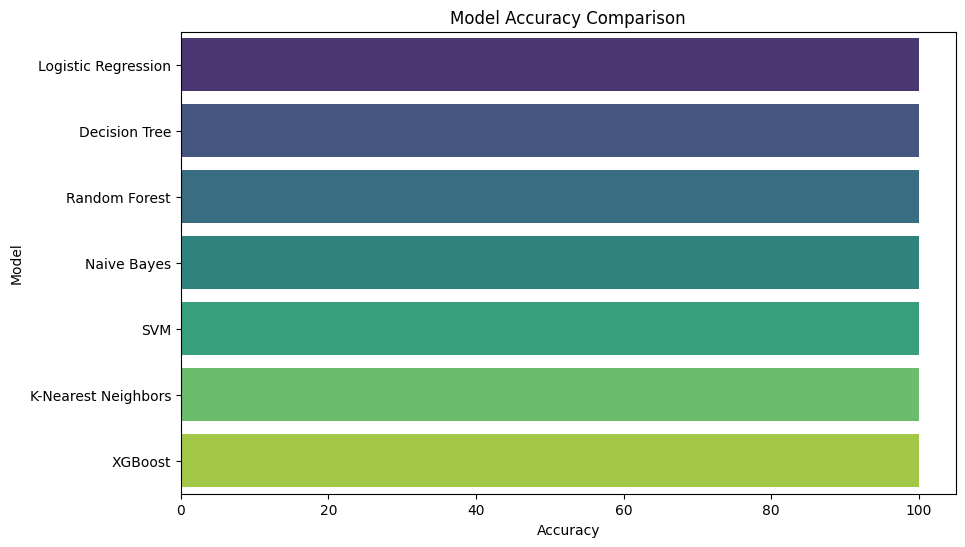

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Naive Bayes': GaussianNB(),
    'SVM': SVC(),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

try:
    from xgboost import XGBClassifier
    models['XGBoost'] = XGBClassifier()
except ImportError:
    print("XGBoost library not found. Skipping XGBoost model.")

accuracies = {}
for name, model in models.items():
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred) * 100
  accuracies[name] = round(accuracy, 2)

results_df = pd.DataFrame(list(accuracies.items()), columns=['Model', 'Accuracy'])
print(results_df)

plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=results_df, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.show()

Object `it` not found.
